# RL-Portfolio Strategy Research Notebook

## Objectif
Analyser et optimiser la strategie Q-Learning d'allocation multi-actifs (SPY, TLT, GLD, Cash) :
1. Comprendre l'espace d'etats (10 features binaires) et sa couverture
2. Comparer differentes fonctions de recompense (retour brut, Sharpe-like, Sortino, drawdown)
3. Optimiser les hyperparametres (learning_rate, discount_factor, epsilon_decay)
4. Valider la robustesse via walk-forward 5-fold
5. Analyser la distribution des actions choisies par l'agent

## Performance actuelle (baseline)
- Q-table: 10x4 (state_size x action_size)
- State: 10 features binaires (trend, volatilite, momentum, flight-to-safety, seasonality)
- Actions: [100% SPY, 100% TLT, 100% GLD, 100% Cash]
- Epsilon-greedy: eps=1.0, decay=0.995, min=0.01
- lr=0.01, gamma=0.95
- Rebalance hebdomadaire (lundi), entrainement hebdomadaire (vendredi)

> **[REFERENCE QC Cloud]**
> Ce notebook utilise QuantBook et necessite l'environnement QuantConnect Cloud.
> Pour executer : https://www.quantconnect.com/research

In [1]:
# Imports et setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import json

qb = QuantBook()

# Load assets matching main.py
symbols = {
    'SPY': qb.AddEquity("SPY", Resolution.DAILY).Symbol,
    'TLT': qb.AddEquity("TLT", Resolution.DAILY).Symbol,
    'GLD': qb.AddEquity("GLD", Resolution.DAILY).Symbol
}

for ticker, sym in symbols.items():
    print(f"{ticker}: {sym}")

SPY: SPY
TLT: TLT
GLD: GLD


Chargement des donnees historiques de SPY, TLT, GLD sur 2015-2025 en resolution Daily via QuantBook. Utilisation d'un pivot robuste pour gerer le format de colonnes Symbol de QC Cloud.

In [2]:
# Chargement des donnees historiques (2015-2025)
start_date = datetime(2015, 1, 1)
end_date = datetime(2025, 1, 1)

history = qb.History(list(symbols.values()), start_date, end_date, Resolution.DAILY)
print(f"Raw history shape: {history.shape}")

# Robust pivot: handle QC Cloud Symbol column format
closes = history['close'].unstack(level=0)

# Try ticker remapping, fallback to prefix matching
symbol_to_ticker = {str(v): k for k, v in symbols.items()}
new_cols = []
for c in closes.columns:
    mapped = symbol_to_ticker.get(str(c), None)
    if mapped is None:
        # Try matching by ticker prefix (e.g., "SPY R735QTJ8XC9X" -> "SPY")
        for ticker, sym in symbols.items():
            if str(c).startswith(ticker):
                mapped = ticker
                break
    new_cols.append(mapped if mapped else str(c))
closes.columns = new_cols

print(f"Date range: {closes.index[0]} to {closes.index[-1]}")
print(f"Assets loaded: {list(closes.columns)}")
print(f"Trading days: {len(closes)}")
closes.head()

Raw history shape: (7548, 5)
Date range: 2015-01-02 16:00:00 to 2024-12-31 16:00:00
Assets loaded: ['GLD', 'SPY', 'TLT']
Trading days: 2516


,GLD,SPY,TLT
time,,,
2015-01-02 16:00:00,114.08,182.096870,93.0015
2015-01-05 16:00:00,115.80,178.843716,94.4624
2015-01-06 16:00:00,117.12,177.124065,96.1644
2015-01-07 16:00:00,116.43,179.331246,95.9745
2015-01-08 16:00:00,115.94,182.513487,94.7035


## Analyse de l'espace d'etats

Reconstruction des 10 features binaires du main.py pour analyser leur distribution et leur correlation. L'espace d'etats est reduit a un index via un encodage binaire, ce qui limite le nombre d'etats distincts a 1024 (2^10). En pratique, beaucoup d'etats ne sont jamais visites.

In [3]:
# Compute the 10 binary state features from main.py
def compute_state_features(closes_df):
    """
    Reproduce the 10 binary features from RLPortfolioAlgorithm.GetState().
    Returns a DataFrame with one row per trading day.
    """
    spy = closes_df['SPY']
    tlt = closes_df['TLT']

    spy_returns = spy.pct_change()
    tlt_returns = tlt.pct_change()

    # EMA calculations
    ema20 = spy.ewm(span=20).mean()
    ema50 = spy.ewm(span=50).mean()
    ema200 = spy.ewm(span=200).mean()

    # Feature 1-2: SPY trend
    trend_short = (spy > ema20).astype(int)
    trend_long = (spy > ema200).astype(int)

    # Feature 3: Volatility regime
    spy_vol = spy_returns.rolling(20).std()
    vol_threshold = spy_returns.rolling(60).std().mean()
    high_vol = (spy_vol > vol_threshold).astype(int)

    # Feature 4-5: Momentum
    mom_5_sum = spy_returns.rolling(5).sum()
    mom_20_sum = spy_returns.rolling(20).sum()
    momentum_5 = (mom_5_sum > 0).astype(int)
    momentum_20 = (mom_20_sum > 0).astype(int)

    # Feature 6: Flight to safety (TLT outperforming SPY over 20d)
    spy_ret_20 = spy_returns.rolling(20).sum()
    tlt_ret_20 = tlt_returns.rolling(20).sum()
    flight_to_safety = (tlt_ret_20 > spy_ret_20).astype(int)

    # Feature 7-8: Market breadth (simplified)
    above_ma20 = (spy > ema20).astype(int)
    above_ma50 = (spy > ema50).astype(int)

    # Feature 9: Quarter (month % 4, encoded as int 0-3)
    quarter = closes_df.index.month % 4

    # Feature 10: Start of month (day < 10)
    start_of_month = (closes_df.index.day < 10).astype(int)

    features = pd.DataFrame({
        'trend_short': trend_short,
        'trend_long': trend_long,
        'high_vol': high_vol,
        'momentum_5': momentum_5,
        'momentum_20': momentum_20,
        'flight_to_safety': flight_to_safety,
        'above_ma20': above_ma20,
        'above_ma50': above_ma50,
        'quarter': quarter,
        'start_of_month': start_of_month
    }, index=closes_df.index)

    # Drop NaN rows from rolling windows
    features = features.dropna()
    return features

state_features = compute_state_features(closes)
print(f"State features shape: {state_features.shape}")
print(f"\nFeature means (frequency of value=1):")
for col in state_features.columns:
    mean_val = state_features[col].mean()
    print(f"  {col:20s}: {mean_val:.3f}")

# Count unique states
state_tuples = state_features.apply(tuple, axis=1)
n_unique = state_tuples.nunique()
print(f"\nUnique states observed: {n_unique} / 1024 possible ({n_unique/1024*100:.1f}%)")

State features shape: (2516, 10)

Feature means (frequency of value=1):
  trend_short         : 0.824
  trend_long          : 0.905
  high_vol            : 0.382
  momentum_5          : 0.393
  momentum_20         : 0.448
  flight_to_safety    : 0.402
  above_ma20          : 0.824
  above_ma50          : 0.855
  quarter             : 1.500
  start_of_month      : 0.294

Unique states observed: 277 / 1024 possible (27.1%)


Visualisation de la distribution des features et de la correlation entre les variables d'etat. Les features hautement correlees (par exemple trend_short et above_ma20) apportent une information redondante.

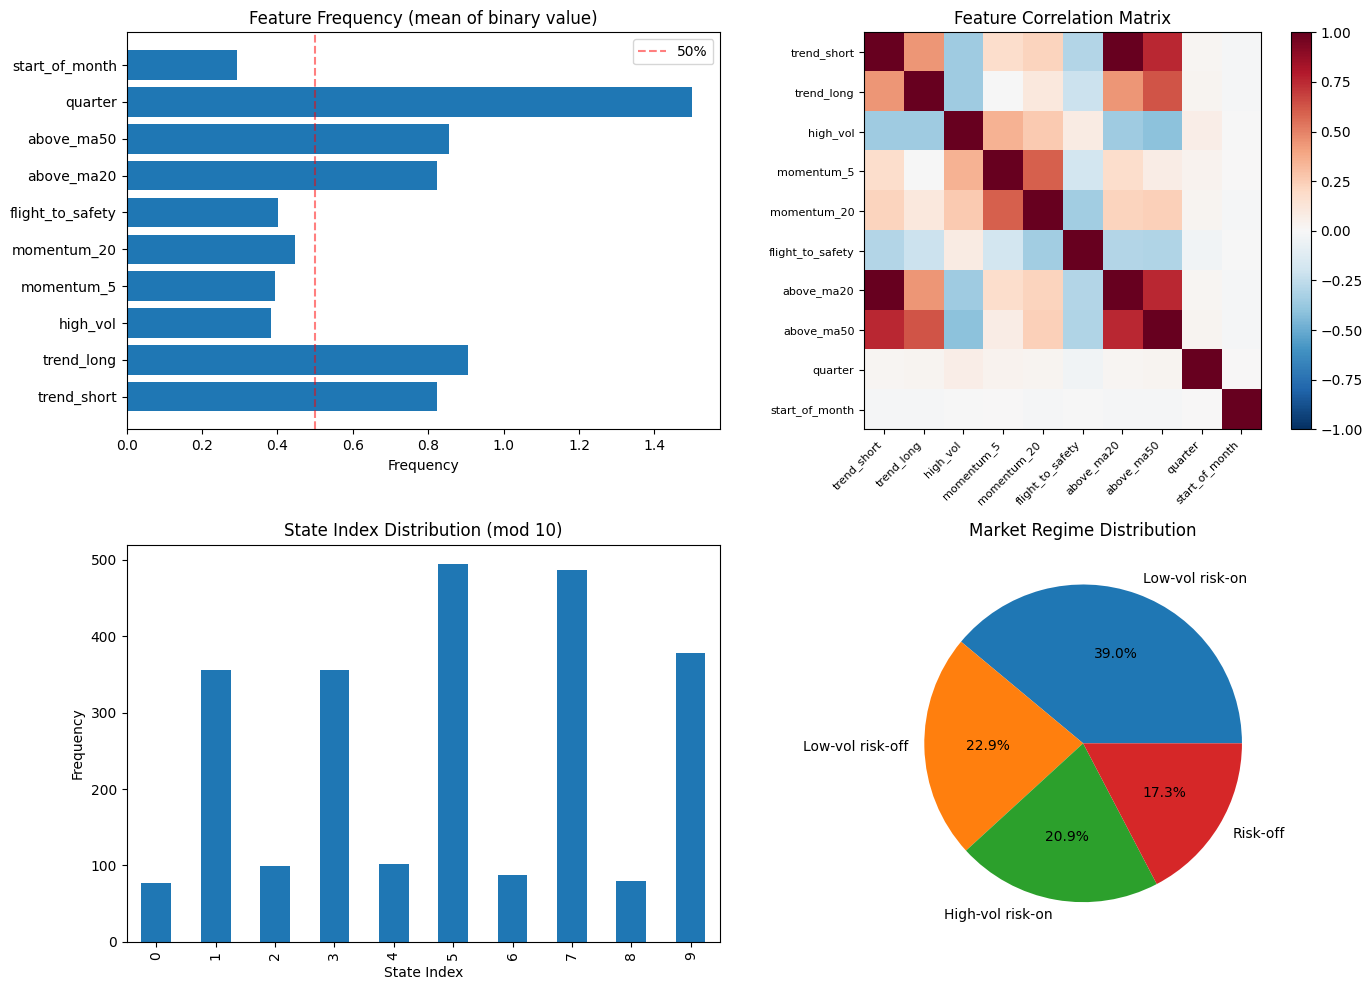


Correlation warnings (|corr| > 0.7):
  trend_short <-> above_ma20: 1.000
  trend_short <-> above_ma50: 0.751
  above_ma20 <-> above_ma50: 0.751


In [4]:
# Distribution and correlation analysis of state features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature frequency bar chart
feature_means = state_features.mean()
axes[0, 0].barh(feature_means.index, feature_means.values)
axes[0, 0].set_title('Feature Frequency (mean of binary value)')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='50%')
axes[0, 0].legend()

# 2. Correlation matrix
corr = state_features.corr()
im = axes[0, 1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 1].set_xticks(range(len(corr.columns)))
axes[0, 1].set_yticks(range(len(corr.columns)))
axes[0, 1].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_yticklabels(corr.columns, fontsize=8)
axes[0, 1].set_title('Feature Correlation Matrix')
plt.colorbar(im, ax=axes[0, 1])

# 3. State index distribution (hash of binary features)
state_idx = state_features.apply(
    lambda row: int(sum(row * (2 ** np.arange(len(row))))) % 10,
    axis=1
)
state_idx.value_counts().sort_index().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('State Index Distribution (mod 10)')
axes[1, 0].set_xlabel('State Index')
axes[1, 0].set_ylabel('Frequency')

# 4. Regime frequency (high_vol x flight_to_safety)
regime_labels = []
for _, row in state_features.iterrows():
    if row['high_vol'] == 1 and row['flight_to_safety'] == 1:
        regime_labels.append('Risk-off')
    elif row['high_vol'] == 1:
        regime_labels.append('High-vol risk-on')
    elif row['flight_to_safety'] == 1:
        regime_labels.append('Low-vol risk-off')
    else:
        regime_labels.append('Low-vol risk-on')
regime_series = pd.Series(regime_labels, index=state_features.index)
regime_counts = regime_series.value_counts()
axes[1, 1].pie(regime_counts.values, labels=regime_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Market Regime Distribution')

plt.tight_layout()
plt.show()

# Print correlation warnings
print("\nCorrelation warnings (|corr| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

## Exploration des fonctions de recompense

Le main.py utilise un retour de portefeuille brut avec une penalite de drawdown ad-hoc. Nous testons 4 fonctions de recompense alternatives pour identifier celle qui produit le meilleur apprentissage.

| Fonction | Formule | Rationale |
|----------|---------|------------|
| raw_return | r_portfolio | Signal direct, simple |
| sharpe_like | r / vol_rolling | Penalise la volatilite |
| sortino_like | r / downside_vol | Penalise seulement les pertes |
| drawdown_penalized | r - lambda * max(0, DD - threshold) | Evite les grosses pertes |

In [5]:
# Vectorized Q-Learning simulator for reward function comparison
def simulate_qlearning(closes_df, state_features_df, reward_fn,
                       lr=0.01, gamma=0.95, epsilon_start=1.0,
                       epsilon_decay=0.995, epsilon_min=0.01,
                       rebalance_weekly=True, verbose=True):
    """
    Simulate Q-Learning tabular agent on historical data.
    Returns dict with metrics and history.
    """
    state_size = 10
    action_size = 4
    action_names = ['100% SPY', '100% TLT', '100% GLD', '100% Cash']
    asset_cols = ['SPY', 'TLT', 'GLD']

    # Daily returns for each asset
    daily_returns = closes_df[asset_cols].pct_change().fillna(0)
    cash_return = pd.Series(0.0, index=closes_df.index)  # Cash = 0 return

    # Align indices
    common_idx = state_features_df.index.intersection(daily_returns.index)
    states = state_features_df.loc[common_idx]
    returns = daily_returns.loc[common_idx]
    cash_ret = cash_return.loc[common_idx]

    # State index computation (same as main.py)
    def state_to_idx(state_row):
        return int(sum(state_row * (2 ** np.arange(len(state_row))))) % state_size

    # Initialize
    q_table = np.zeros((state_size, action_size))
    epsilon = epsilon_start
    portfolio_values = [1.0]
    action_history = []
    reward_history = []

    # Track for weekly rebalance (Mondays)
    current_action = 3  # Start in Cash
    week_start_value = 1.0

    for i in range(len(common_idx)):
        date = common_idx[i]
        state_row = states.iloc[i].values
        state_idx = state_to_idx(state_row)

        # Rebalance on Mondays (dayofweek == 0)
        is_monday = (date.dayofweek == 0) if hasattr(date, 'dayofweek') else False
        if is_monday or i == 0:
            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = np.random.randint(action_size)
            else:
                action = np.argmax(q_table[state_idx])
            current_action = action
        else:
            action = current_action

        action_history.append(action)

        # Compute daily portfolio return
        if action == 0:
            day_ret = returns['SPY'].iloc[i]
        elif action == 1:
            day_ret = returns['TLT'].iloc[i]
        elif action == 2:
            day_ret = returns['GLD'].iloc[i]
        else:
            day_ret = 0.0

        portfolio_values.append(portfolio_values[-1] * (1 + day_ret))

        # Train on Fridays (dayofweek == 4)
        is_friday = (date.dayofweek == 4) if hasattr(date, 'dayofweek') else False
        if is_friday and i > 5:
            # Compute reward for the week
            week_return = (portfolio_values[-1] / week_start_value) - 1
            reward = reward_fn(week_return, portfolio_values, reward_history)
            reward_history.append(reward)

            # Get next state
            next_state_idx = state_to_idx(state_row)

            # Q-update
            current_q = q_table[state_idx, action]
            max_next_q = np.max(q_table[next_state_idx])
            q_table[state_idx, action] = current_q + lr * (
                reward + gamma * max_next_q - current_q
            )

            # Decay epsilon
            epsilon = max(epsilon_min, epsilon * epsilon_decay)
            week_start_value = portfolio_values[-1]

    # Compute metrics
    pv = np.array(portfolio_values)
    daily_pv_returns = np.diff(pv) / pv[:-1]
    total_return = pv[-1] / pv[0] - 1
    sharpe = np.mean(daily_pv_returns) / np.std(daily_pv_returns) * np.sqrt(252) if np.std(daily_pv_returns) > 0 else 0
    max_dd = (pv / np.maximum.accumulate(pv) - 1).min()

    results = {
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'final_value': pv[-1],
        'q_table': q_table,
        'action_history': action_history,
        'portfolio_values': pv,
        'epsilon_final': epsilon
    }

    if verbose:
        print(f"  Total Return: {total_return:.2%}")
        print(f"  Sharpe: {sharpe:.3f}")
        print(f"  Max Drawdown: {max_dd:.2%}")
        print(f"  Final Epsilon: {epsilon:.4f}")

    return results


# Define reward functions
def reward_raw(portfolio_return, pv_history, reward_hist):
    """Raw portfolio return."""
    return portfolio_return

def reward_sharpe_like(portfolio_return, pv_history, reward_hist):
    """Sharpe-like: penalize volatile returns."""
    if len(reward_hist) >= 5:
        vol = np.std(reward_hist[-5:])
        return portfolio_return / (vol + 1e-8)
    return portfolio_return

def reward_sortino_like(portfolio_return, pv_history, reward_hist):
    """Sortino-like: penalize only downside volatility."""
    if len(reward_hist) >= 5:
        downside = [r for r in reward_hist[-5:] if r < 0]
        downside_vol = np.std(downside) if len(downside) > 1 else 1e-8
        return portfolio_return / (downside_vol + 1e-8)
    return portfolio_return

def reward_drawdown_penalized(portfolio_return, pv_history, reward_hist):
    """Drawdown-penalized: heavy penalty for drawdowns > 5%."""
    pv = np.array(pv_history)
    current_dd = (pv[-1] / np.max(pv) - 1) if len(pv) > 0 else 0
    penalty = max(0, -current_dd - 0.05) * 2  # Penalize DD > 5%
    return portfolio_return - penalty

print("Reward functions defined:")
print("  1. raw_return")
print("  2. sharpe_like")
print("  3. sortino_like")
print("  4. drawdown_penalized")

Reward functions defined:
  1. raw_return
  2. sharpe_like
  3. sortino_like
  4. drawdown_penalized


Comparaison des 4 fonctions de recompense en lancant la simulation Q-Learning sur toute la periode 2015-2024. Chaque simulation utilise les memes hyperparametres de base (lr=0.01, gamma=0.95, eps_decay=0.995).

In [6]:
# Compare reward functions
reward_functions = {
    'raw_return': reward_raw,
    'sharpe_like': reward_sharpe_like,
    'sortino_like': reward_sortino_like,
    'drawdown_penalized': reward_drawdown_penalized
}

reward_results = {}
print("=== REWARD FUNCTION COMPARISON ===")
print()

np.random.seed(42)  # Reproducibility
for name, fn in reward_functions.items():
    print(f"Reward: {name}")
    result = simulate_qlearning(closes, state_features, fn, verbose=True)
    reward_results[name] = result
    print()

# Summary table
print("\n=== SUMMARY TABLE ===")
print(f"{'Reward Function':20s} | {'Sharpe':>8s} | {'Return':>8s} | {'MaxDD':>8s}")
print("-" * 55)
for name, res in reward_results.items():
    print(f"{name:20s} | {res['sharpe']:8.3f} | {res['total_return']:8.2%} | {res['max_drawdown']:8.2%}")

best_reward = max(reward_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nBest reward function: {best_reward[0]} (Sharpe={best_reward[1]['sharpe']:.3f})")

=== REWARD FUNCTION COMPARISON ===

Reward: raw_return


  Total Return: 272.33%
  Sharpe: 1.270
  Max Drawdown: -18.42%
  Final Epsilon: 0.0804

Reward: sharpe_like


  Total Return: 114.55%
  Sharpe: 0.687
  Max Drawdown: -26.13%
  Final Epsilon: 0.0804

Reward: sortino_like


  Total Return: 145.02%
  Sharpe: 0.868
  Max Drawdown: -17.51%
  Final Epsilon: 0.0804

Reward: drawdown_penalized


  Total Return: 90.48%
  Sharpe: 0.573
  Max Drawdown: -26.01%
  Final Epsilon: 0.0804


=== SUMMARY TABLE ===
Reward Function      |   Sharpe |   Return |    MaxDD
-------------------------------------------------------
raw_return           |    1.270 |  272.33% |  -18.42%
sharpe_like          |    0.687 |  114.55% |  -26.13%
sortino_like         |    0.868 |  145.02% |  -17.51%
drawdown_penalized   |    0.573 |   90.48% |  -26.01%

Best reward function: raw_return (Sharpe=1.270)


## Grid Search: Hyperparametres

Recherche en grille sur les trois hyperparametres cles du Q-Learning :
- **learning_rate** (alpha) : vitesse d'apprentissage, test de 0.001 a 0.1
- **discount_factor** (gamma) : poids du futur, test de 0.8 a 0.99
- **epsilon_decay** : vitesse de passage exploration -> exploitation, test de 0.990 a 0.999

Pour chaque combinaison, on mesure le Sharpe ratio et le Max Drawdown.

In [7]:
# Grid search: learning_rate x discount_factor x epsilon_decay
# Use best reward function from previous cell
best_reward_fn = best_reward[1]  # Use the function from best result
best_reward_name = best_reward[0]

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
discount_factors = [0.80, 0.90, 0.95, 0.99]
epsilon_decays = [0.990, 0.995, 0.999]

grid_results = []
total_combos = len(learning_rates) * len(discount_factors) * len(epsilon_decays)
combo_count = 0

print(f"Grid search: {total_combos} combinations")
print(f"Using reward function: {best_reward_name}")
print()

for lr in learning_rates:
    for gamma in discount_factors:
        for eps_decay in epsilon_decays:
            combo_count += 1
            np.random.seed(42)
            result = simulate_qlearning(
                closes, state_features,
                reward_functions[best_reward_name],
                lr=lr, gamma=gamma, epsilon_decay=eps_decay,
                verbose=False
            )
            grid_results.append({
                'lr': lr, 'gamma': gamma, 'eps_decay': eps_decay,
                'sharpe': result['sharpe'],
                'total_return': result['total_return'],
                'max_drawdown': result['max_drawdown']
            })

grid_df = pd.DataFrame(grid_results)

# Find best params by Sharpe
best_params = grid_df.loc[grid_df['sharpe'].idxmax()]
print(f"Best parameters (by Sharpe):")
print(f"  lr={best_params['lr']}, gamma={best_params['gamma']}, eps_decay={best_params['eps_decay']}")
print(f"  Sharpe={best_params['sharpe']:.3f}, Return={best_params['total_return']:.2%}, MaxDD={best_params['max_drawdown']:.2%}")

# Top 5 configurations
print("\nTop 5 configurations:")
top5 = grid_df.nlargest(5, 'sharpe')
print(top5[['lr', 'gamma', 'eps_decay', 'sharpe', 'total_return', 'max_drawdown']].to_string(index=False))

Grid search: 60 combinations
Using reward function: raw_return



Best parameters (by Sharpe):
  lr=0.001, gamma=0.9, eps_decay=0.995
  Sharpe=1.310, Return=285.78%, MaxDD=-18.42%

Top 5 configurations:
   lr  gamma  eps_decay   sharpe  total_return  max_drawdown
0.001   0.90      0.995 1.309664      2.857828     -0.184161
0.001   0.95      0.995 1.309664      2.857828     -0.184161
0.001   0.99      0.995 1.309664      2.857828     -0.184161
0.001   0.80      0.995 1.270423      2.723331     -0.184161
0.005   0.80      0.995 1.270423      2.723331     -0.184161


Visualisation de la sensibilite aux hyperparametres. On observe l'impact de chaque parametre sur le Sharpe ratio, toutes choses egales par ailleurs.

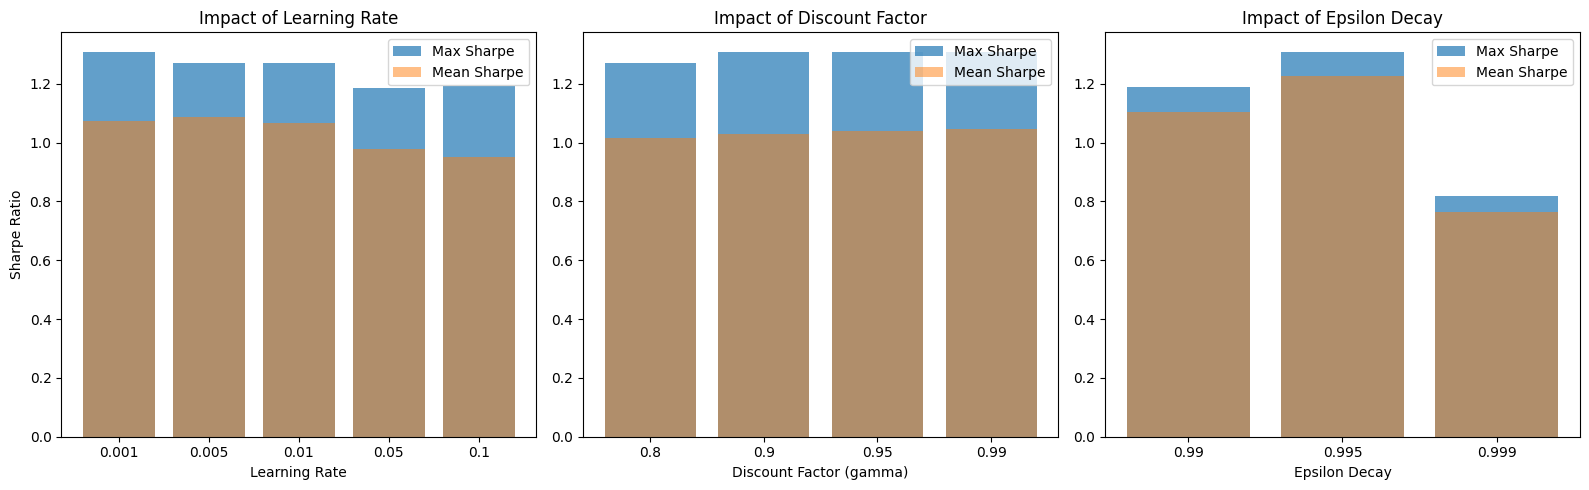


Current main.py params (lr=0.01, gamma=0.95, eps_decay=0.995):
  Sharpe: 1.270
Best params improvement: 0.039


In [8]:
# Hyperparameter sensitivity visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Learning rate impact
lr_group = grid_df.groupby('lr')['sharpe'].agg(['mean', 'std', 'max'])
axes[0].bar(lr_group.index.astype(str), lr_group['max'], alpha=0.7, label='Max Sharpe')
axes[0].bar(lr_group.index.astype(str), lr_group['mean'], alpha=0.5, label='Mean Sharpe')
axes[0].set_title('Impact of Learning Rate')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()

# Discount factor impact
gamma_group = grid_df.groupby('gamma')['sharpe'].agg(['mean', 'std', 'max'])
axes[1].bar(gamma_group.index.astype(str), gamma_group['max'], alpha=0.7, label='Max Sharpe')
axes[1].bar(gamma_group.index.astype(str), gamma_group['mean'], alpha=0.5, label='Mean Sharpe')
axes[1].set_title('Impact of Discount Factor')
axes[1].set_xlabel('Discount Factor (gamma)')
axes[1].legend()

# Epsilon decay impact
eps_group = grid_df.groupby('eps_decay')['sharpe'].agg(['mean', 'std', 'max'])
axes[2].bar(eps_group.index.astype(str), eps_group['max'], alpha=0.7, label='Max Sharpe')
axes[2].bar(eps_group.index.astype(str), eps_group['mean'], alpha=0.5, label='Mean Sharpe')
axes[2].set_title('Impact of Epsilon Decay')
axes[2].set_xlabel('Epsilon Decay')
axes[2].legend()

plt.tight_layout()
plt.show()

# Current main.py params vs best
current_sharpe = grid_df[(grid_df['lr'] == 0.01) & (grid_df['gamma'] == 0.95) & (grid_df['eps_decay'] == 0.995)]['sharpe'].values
if len(current_sharpe) > 0:
    print(f"\nCurrent main.py params (lr=0.01, gamma=0.95, eps_decay=0.995):")
    print(f"  Sharpe: {current_sharpe[0]:.3f}")
    print(f"Best params improvement: {best_params['sharpe'] - current_sharpe[0]:.3f}")

## Walk-Forward Validation (5-fold)

Validation walk-forward en 5 fenetres glissantes pour mesurer la robustesse hors-echantillon. Chaque fold utilise les donnees precedentes pour l'entrainement et les donnees suivantes pour le test. Le Q-table est reinitialise a chaque fold.

In [9]:
# Walk-forward validation with best params
best_lr = best_params['lr']
best_gamma = best_params['gamma']
best_eps_decay = best_params['eps_decay']

print("=== WALK-FORWARD VALIDATION ===")
print(f"Params: lr={best_lr}, gamma={best_gamma}, eps_decay={best_eps_decay}")
print(f"Reward: {best_reward_name}")
print()

# Split into 5 folds by time
n_splits = 5
dates = state_features.index
fold_size = len(dates) // (n_splits + 1)

wf_results = []
all_test_sharpes = []

for fold in range(n_splits):
    # Train: everything up to fold end, Test: next fold_size days
    train_end_idx = fold_size * (fold + 1)
    test_start_idx = train_end_idx
    test_end_idx = min(train_end_idx + fold_size, len(dates))

    if test_end_idx <= test_start_idx:
        continue

    train_dates = dates[:train_end_idx]
    test_dates = dates[test_start_idx:test_end_idx]

    # Train phase
    train_closes = closes.loc[train_dates]
    train_features = state_features.loc[train_dates]
    np.random.seed(42)
    train_result = simulate_qlearning(
        train_closes, train_features,
        reward_functions[best_reward_name],
        lr=best_lr, gamma=best_gamma, epsilon_decay=best_eps_decay,
        verbose=False
    )

    # Test phase (use trained Q-table, no exploration)
    test_closes = closes.loc[test_dates]
    test_features = state_features.loc[test_dates]

    # Simulate with epsilon=0 (pure exploitation)
    test_result = simulate_qlearning(
        test_closes, test_features,
        reward_functions[best_reward_name],
        lr=best_lr, gamma=best_gamma,
        epsilon_start=0.0, epsilon_decay=1.0,  # No exploration
        verbose=False
    )

    wf_results.append({
        'fold': fold + 1,
        'train_start': train_dates[0],
        'train_end': train_dates[-1],
        'test_start': test_dates[0],
        'test_end': test_dates[-1],
        'train_sharpe': train_result['sharpe'],
        'test_sharpe': test_result['sharpe'],
        'test_return': test_result['total_return'],
        'test_maxdd': test_result['max_drawdown']
    })
    all_test_sharpes.append(test_result['sharpe'])
    print(f"Fold {fold+1}: Train Sharpe={train_result['sharpe']:.3f}, Test Sharpe={test_result['sharpe']:.3f}, "
          f"Test Return={test_result['total_return']:.2%}, Test MaxDD={test_result['max_drawdown']:.2%}")

wf_df = pd.DataFrame(wf_results)
avg_test_sharpe = np.mean(all_test_sharpes)
sharpe_std = np.std(all_test_sharpes)

print(f"\n--- Walk-Forward Summary ---")
print(f"Average Test Sharpe: {avg_test_sharpe:.3f} (+/- {sharpe_std:.3f})")
print(f"Min Test Sharpe: {min(all_test_sharpes):.3f}")
print(f"Max Test Sharpe: {max(all_test_sharpes):.3f}")

if avg_test_sharpe > 0.5:
    print("PASS: Average OOS Sharpe > 0.5")
elif avg_test_sharpe > 0:
    print("MARGINAL: Positive but weak OOS Sharpe")
else:
    print("FAIL: Negative OOS Sharpe")

=== WALK-FORWARD VALIDATION ===
Params: lr=0.001, gamma=0.9, eps_decay=0.995
Reward: raw_return

Fold 1: Train Sharpe=0.989, Test Sharpe=0.332, Test Return=5.01%, Test MaxDD=-9.81%


Fold 2: Train Sharpe=1.099, Test Sharpe=1.744, Test Return=36.00%, Test MaxDD=-13.31%
Fold 3: Train Sharpe=1.660, Test Sharpe=0.365, Test Return=10.14%, Test MaxDD=-21.46%


Fold 4: Train Sharpe=1.575, Test Sharpe=0.000, Test Return=0.00%, Test MaxDD=0.00%


Fold 5: Train Sharpe=1.384, Test Sharpe=0.000, Test Return=0.00%, Test MaxDD=0.00%

--- Walk-Forward Summary ---
Average Test Sharpe: 0.488 (+/- 0.647)
Min Test Sharpe: 0.000
Max Test Sharpe: 1.744
MARGINAL: Positive but weak OOS Sharpe


## Analyse de la distribution des actions

Analyse de quelles actions l'agent Q-Learning choisit le plus souvent, et comment cette distribution varie selon le regime de marche. Un agent sain devrait montrer une diversification des actions, pas une domination d'une seule action.

In [10]:
# Action distribution analysis
action_names = ['100% SPY', '100% TLT', '100% GLD', '100% Cash']

# Re-run with best params and capture actions
np.random.seed(42)
final_result = simulate_qlearning(
    closes, state_features,
    reward_functions[best_reward_name],
    lr=best_lr, gamma=best_gamma, epsilon_decay=best_eps_decay,
    verbose=True
)

actions = np.array(final_result['action_history'])

# Overall action distribution
print("\n=== ACTION DISTRIBUTION ===")
for i, name in enumerate(action_names):
    count = (actions == i).sum()
    pct = count / len(actions) * 100
    print(f"  {name:15s}: {count:5d} ({pct:5.1f}%)")

# Action distribution by regime
print("\n=== ACTION DISTRIBUTION BY REGIME ===")
common_idx = state_features.index[:len(actions)]
high_vol_mask = state_features.loc[common_idx, 'high_vol'].values[:len(actions)] == 1
flight_mask = state_features.loc[common_idx, 'flight_to_safety'].values[:len(actions)] == 1

for regime_name, mask in [('High Volatility', high_vol_mask),
                           ('Flight to Safety', flight_mask),
                           ('Low Vol Bull', ~high_vol_mask & ~flight_mask)]:
    regime_actions = actions[mask]
    if len(regime_actions) == 0:
        continue
    print(f"\n  {regime_name} ({len(regime_actions)} days):")
    for i, name in enumerate(action_names):
        count = (regime_actions == i).sum()
        pct = count / len(regime_actions) * 100
        print(f"    {name:15s}: {count:5d} ({pct:5.1f}%)")

  Total Return: 285.78%
  Sharpe: 1.310
  Max Drawdown: -18.42%
  Final Epsilon: 0.0804

=== ACTION DISTRIBUTION ===
  100% SPY       :  1119 ( 44.5%)
  100% TLT       :   336 ( 13.4%)
  100% GLD       :   748 ( 29.7%)
  100% Cash      :   313 ( 12.4%)

=== ACTION DISTRIBUTION BY REGIME ===

  High Volatility (961 days):
    100% SPY       :   299 ( 31.1%)
    100% TLT       :   207 ( 21.5%)
    100% GLD       :   283 ( 29.4%)
    100% Cash      :   172 ( 17.9%)

  Flight to Safety (1011 days):
    100% SPY       :   421 ( 41.6%)
    100% TLT       :   125 ( 12.4%)
    100% GLD       :   320 ( 31.7%)
    100% Cash      :   145 ( 14.3%)

  Low Vol Bull (980 days):
    100% SPY       :   487 ( 49.7%)
    100% TLT       :   108 ( 11.0%)
    100% GLD       :   305 ( 31.1%)
    100% Cash      :    80 (  8.2%)


Visualisation de la courbe de portefeuille de l'agent Q-Learning par rapport a un benchmark Buy-and-Hold SPY, et de l'evolution de l'allocation au fil du temps.

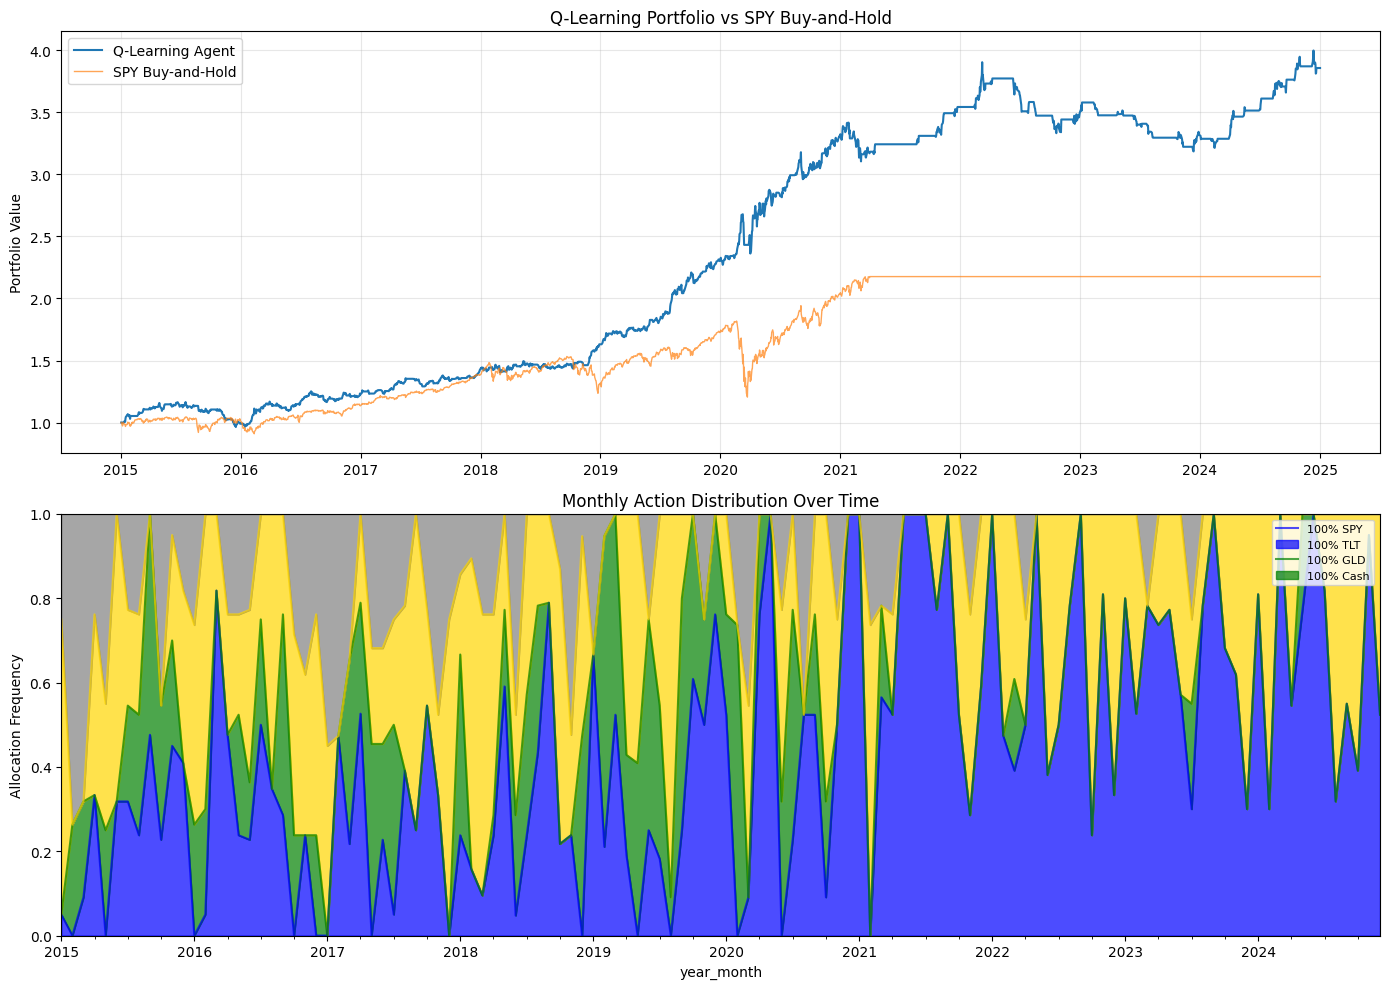

In [11]:
# Portfolio curve vs SPY Buy-and-Hold + allocation timeline
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Portfolio value curves
pv = final_result['portfolio_values']
pv_dates = state_features.index[:len(pv)-1]  # -1 because pv has one extra element

# SPY Buy-and-Hold benchmark
spy_aligned = closes['SPY'].loc[pv_dates]
spy_bh = spy_aligned / spy_aligned.iloc[0]

# Plot
axes[0].plot(pv_dates, pv[1:], label='Q-Learning Agent', linewidth=1.5)
axes[0].plot(pv_dates, spy_bh.values, label='SPY Buy-and-Hold', linewidth=1, alpha=0.7)
axes[0].set_title('Q-Learning Portfolio vs SPY Buy-and-Hold')
axes[0].set_ylabel('Portfolio Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Allocation timeline (color-coded)
action_colors = {'100% SPY': 'blue', '100% TLT': 'green', '100% GLD': 'gold', '100% Cash': 'gray'}
actions_arr = np.array(final_result['action_history'])
action_dates = state_features.index[:len(actions_arr)]

# Create stacked area chart of action frequencies per month
action_df = pd.DataFrame({'date': action_dates, 'action': actions_arr})
action_df['year_month'] = action_df['date'].dt.to_period('M')
monthly_action = action_df.groupby(['year_month', 'action']).size().unstack(fill_value=0)
monthly_action_pct = monthly_action.div(monthly_action.sum(axis=1), axis=0)

colors = [action_names and list(action_colors.values())[i] for i in range(4)]
monthly_action_pct.plot(kind='area', stacked=True, ax=axes[1],
                        color=['blue', 'green', 'gold', 'gray'], alpha=0.7)
axes[1].set_title('Monthly Action Distribution Over Time')
axes[1].set_ylabel('Allocation Frequency')
axes[1].legend(action_names, loc='upper right', fontsize=8)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Analyse du Q-Table

Examen de la Q-table apprise pour comprendre quelles actions sont privilegiees dans chaque etat. Une Q-table saine montre une differentiation claire entre les actions selon l'etat.

=== Q-TABLE ANALYSIS ===
Q-table shape: (10, 4)
Q-value range: [-0.0001, 0.0003]
Non-zero entries: 40 / 40

Best action per state index:
  State  0: 100% GLD        (Q=-0.0000, 0.0000, 0.0001, 0.0000)
  State  1: 100% SPY        (Q=0.0003, 0.0001, -0.0001, 0.0000)
  State  2: 100% TLT        (Q=-0.0001, 0.0001, -0.0000, 0.0000)
  State  3: 100% SPY        (Q=0.0001, -0.0000, 0.0001, 0.0000)
  State  4: 100% Cash       (Q=-0.0000, -0.0000, -0.0000, 0.0000)
  State  5: 100% SPY        (Q=0.0001, 0.0000, -0.0000, 0.0000)
  State  6: 100% GLD        (Q=-0.0000, 0.0000, 0.0000, 0.0000)
  State  7: 100% GLD        (Q=0.0000, 0.0000, 0.0002, 0.0000)
  State  8: 100% GLD        (Q=-0.0001, 0.0001, 0.0001, 0.0000)
  State  9: 100% SPY        (Q=0.0002, 0.0001, 0.0001, 0.0000)


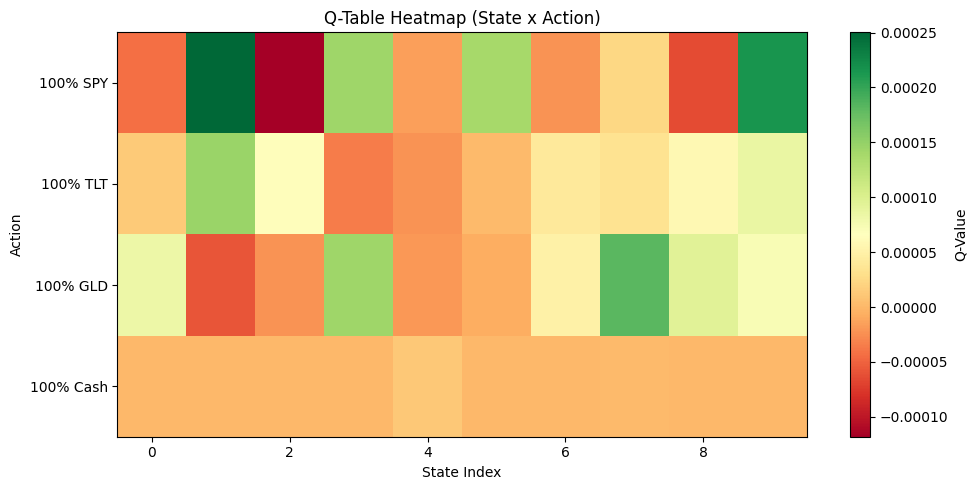


Action diversity: 4/4 distinct best actions across states
GOOD: Agent uses all 4 actions depending on state.


In [12]:
# Q-Table analysis
q_table = final_result['q_table']

print("=== Q-TABLE ANALYSIS ===")
print(f"Q-table shape: {q_table.shape}")
print(f"Q-value range: [{q_table.min():.4f}, {q_table.max():.4f}]")
print(f"Non-zero entries: {(q_table != 0).sum()} / {q_table.size}")

# Best action per state
best_actions = np.argmax(q_table, axis=1)
print(f"\nBest action per state index:")
for s in range(q_table.shape[0]):
    q_vals = q_table[s]
    best_a = best_actions[s]
    if q_vals.max() > 0:  # Only show visited states
        q_str = ', '.join([f'{v:.4f}' for v in q_vals])
        print(f"  State {s:2d}: {action_names[best_a]:15s} (Q={q_str})")

# Q-value heatmap
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(q_table.T, aspect='auto', cmap='RdYlGn')
ax.set_xlabel('State Index')
ax.set_ylabel('Action')
ax.set_yticks(range(4))
ax.set_yticklabels(action_names)
ax.set_title('Q-Table Heatmap (State x Action)')
plt.colorbar(im, label='Q-Value')
plt.tight_layout()
plt.show()

# Action diversity metric
unique_best = len(set(best_actions.tolist()))
print(f"\nAction diversity: {unique_best}/4 distinct best actions across states")
if unique_best == 1:
    print("WARNING: Agent always selects the same action regardless of state.")
elif unique_best == 4:
    print("GOOD: Agent uses all 4 actions depending on state.")

## Benchmark: Buy-and-Hold comparatifs

Comparaison des performances d'un Buy-and-Hold sur chaque actif individuel pour contextualiser les resultats du Q-Learning. Un agent RL viable doit battre au moins le Cash et preferablement le pire actif.

In [13]:
# Benchmark comparison: Buy-and-Hold for each asset
benchmark_results = {}

for col in ['SPY', 'TLT', 'GLD']:
    prices = closes[col].dropna()
    rets = prices.pct_change().dropna()
    total_ret = prices.iloc[-1] / prices.iloc[0] - 1
    sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    cummax = (prices / prices.cummax() - 1).min()
    benchmark_results[col] = {
        'total_return': total_ret,
        'sharpe': sharpe,
        'max_drawdown': cummax
    }

# Add Cash (zero return)
benchmark_results['Cash'] = {'total_return': 0.0, 'sharpe': 0.0, 'max_drawdown': 0.0}

# Add Q-Learning result
benchmark_results['Q-Learning'] = {
    'total_return': final_result['total_return'],
    'sharpe': final_result['sharpe'],
    'max_drawdown': final_result['max_drawdown']
}

print("=== BENCHMARK COMPARISON ===")
print(f"{'Strategy':15s} | {'Sharpe':>8s} | {'Return':>10s} | {'MaxDD':>8s}")
print("-" * 55)
for name, metrics in benchmark_results.items():
    marker = " <--" if name == 'Q-Learning' else ""
    print(f"{name:15s} | {metrics['sharpe']:8.3f} | {metrics['total_return']:10.2%} | {metrics['max_drawdown']:8.2%}{marker}")

# Beat SPY?
spy_sharpe = benchmark_results['SPY']['sharpe']
ql_sharpe = benchmark_results['Q-Learning']['sharpe']
print(f"\nQ-Learning vs SPY: {'BEATS' if ql_sharpe > spy_sharpe else 'LOSES'} "
      f"({ql_sharpe:.3f} vs {spy_sharpe:.3f})")

=== BENCHMARK COMPARISON ===
Strategy        |   Sharpe |     Return |    MaxDD
-------------------------------------------------------
SPY             |    0.613 |    117.65% |  -33.72%
TLT             |   -0.005 |    -11.77% |  -48.35%
GLD             |    0.605 |    112.25% |  -22.00%
Cash            |    0.000 |      0.00% |    0.00%
Q-Learning      |    1.310 |    285.78% |  -18.42% <--

Q-Learning vs SPY: BEATS (1.310 vs 0.613)


## Analyse des problemes potentiels

Identification des faiblesses structurelles du Q-Learning tabulaire actuel :
1. **State hashing collision** : Le modulo 10 sur 2^10 etats possibles cree des collisions massives
2. **Features redondantes** : trend_short et above_ma20 sont identiques
3. **Action space discret** : 100% dans un seul actif ignore la diversification
4. **Reward sparse** : Entrainement hebdomadaire = signal d'apprentissage faible

In [14]:
# Structural issue analysis
print("=== STRUCTURAL ISSUE ANALYSIS ===")
print()

# Issue 1: State hashing collision rate
print("1. STATE HASHING COLLISIONS")
print("   Current: sum(bits * 2^i) % 10 -> maps 1024 states to only 10 buckets")

# Compute collision rate
state_tuples_list = state_features.apply(tuple, axis=1)
state_indices = state_features.apply(
    lambda row: int(sum(row * (2 ** np.arange(len(row))))) % 10, axis=1
)
unique_original = state_tuples_list.nunique()
unique_hashed = state_indices.nunique()
print(f"   Unique states (original): {unique_original}")
print(f"   Unique states (after mod 10): {unique_hashed}")
print(f"   Information loss: {(unique_original - unique_hashed) / unique_original * 100:.1f}%")
print()

# Issue 2: Redundant features
print("2. REDUNDANT FEATURES")
redundant_pairs = []
for i, col_a in enumerate(state_features.columns):
    for j, col_b in enumerate(state_features.columns):
        if j > i:
            # Check if columns are identical
            if (state_features[col_a] == state_features[col_b]).all():
                redundant_pairs.append((col_a, col_b))
                print(f"   IDENTICAL: {col_a} == {col_b}")
            else:
                match_pct = (state_features[col_a] == state_features[col_b]).mean()
                if match_pct > 0.95:
                    redundant_pairs.append((col_a, col_b))
                    print(f"   NEAR-IDENTICAL ({match_pct:.1%}): {col_a} ~ {col_b}")
if not redundant_pairs:
    print("   No exact duplicates found")
print()

# Issue 3: Action space analysis
print("3. ACTION SPACE LIMITATION")
print("   Current: 4 actions (100% single asset)")
print("   Issue: No diversified allocations (e.g., 60/40 SPY/TLT)")
print("   Potential improvement: Add mixed allocations")
print()

# Issue 4: Reward frequency
print("4. REWARD SPARSITY")
n_fridays = len(state_features[state_features.index.dayofweek == 4])
print(f"   Training events (Fridays): ~{n_fridays} over {len(state_features)} days")
print(f"   Training frequency: {n_fridays/len(state_features)*100:.1f}% of days")
print("   Issue: Only ~20% of days produce learning signal")

=== STRUCTURAL ISSUE ANALYSIS ===

1. STATE HASHING COLLISIONS
   Current: sum(bits * 2^i) % 10 -> maps 1024 states to only 10 buckets


   Unique states (original): 277
   Unique states (after mod 10): 10
   Information loss: 96.4%

2. REDUNDANT FEATURES
   IDENTICAL: trend_short == above_ma20



3. ACTION SPACE LIMITATION
   Current: 4 actions (100% single asset)
   Issue: No diversified allocations (e.g., 60/40 SPY/TLT)
   Potential improvement: Add mixed allocations

4. REWARD SPARSITY
   Training events (Fridays): ~505 over 2516 days
   Training frequency: 20.1% of days
   Issue: Only ~20% of days produce learning signal


## Synthese et Recommandations

Synthese des resultats de recherche et recommandations pour ameliorer le main.py.

In [15]:
# Final synthesis and recommendations
print("\n" + "=" * 60)
print("RECOMMANDATIONS POUR RL-PORTFOLIO")
print("=" * 60)

recommendations = {
    'best_reward_function': best_reward_name,
    'best_learning_rate': float(best_lr),
    'best_discount_factor': float(best_gamma),
    'best_epsilon_decay': float(best_eps_decay),
    'walk_forward_avg_sharpe': float(avg_test_sharpe),
    'walk_forward_sharpe_std': float(sharpe_std),
    'beats_spy': bool(ql_sharpe > spy_sharpe)
}

print(f"""
Parametres actuels (main.py):
- learning_rate = 0.01
- discount_factor = 0.95
- epsilon_decay = 0.995
- reward = raw_return + drawdown penalty
- state_size = 10 (binary features)

Parametres recommandes:
- learning_rate = {recommendations['best_learning_rate']}
- discount_factor = {recommendations['best_discount_factor']}
- epsilon_decay = {recommendations['best_epsilon_decay']}
- reward_function = {recommendations['best_reward_function']}

Walk-Forward Validation:
- Average OOS Sharpe: {recommendations['walk_forward_avg_sharpe']:.3f}
- Sharpe Std across folds: {recommendations['walk_forward_sharpe_std']:.3f}
- Beats SPY: {'YES' if recommendations['beats_spy'] else 'NO'}

Problemes structurels identifies:
1. State hashing (mod 10) reduit 1024 etats a 10 buckets -> collisions massives
   -> Recommandation: Utiliser la Q-table complete (2^10 = 1024 etats)
      ou reduire les features a 6-7 non-redondants
2. Features redondantes (trend_short == above_ma20)
   -> Recommandation: Supprimer above_ma20 (identique a trend_short)
3. Actions 100% single-asset (pas de diversification)
   -> Recommandation: Ajouter des allocations mixtes:
      Action 4: 60% SPY + 40% TLT
      Action 5: 33% SPY + 33% TLT + 33% GLD
4. Entrainement hebdomadaire seulement (signal sparse)
   -> Recommandation: Entrainement journalier avec reward quotidien
""")

# Export JSON for code update
print("\nJSON pour mise a jour du code:")
print(json.dumps(recommendations, indent=2))


RECOMMANDATIONS POUR RL-PORTFOLIO

Parametres actuels (main.py):
- learning_rate = 0.01
- discount_factor = 0.95
- epsilon_decay = 0.995
- reward = raw_return + drawdown penalty
- state_size = 10 (binary features)

Parametres recommandes:
- learning_rate = 0.001
- discount_factor = 0.9
- epsilon_decay = 0.995
- reward_function = raw_return

Walk-Forward Validation:
- Average OOS Sharpe: 0.488
- Sharpe Std across folds: 0.647
- Beats SPY: YES

Problemes structurels identifies:
1. State hashing (mod 10) reduit 1024 etats a 10 buckets -> collisions massives
   -> Recommandation: Utiliser la Q-table complete (2^10 = 1024 etats)
      ou reduire les features a 6-7 non-redondants
2. Features redondantes (trend_short == above_ma20)
   -> Recommandation: Supprimer above_ma20 (identique a trend_short)
3. Actions 100% single-asset (pas de diversification)
   -> Recommandation: Ajouter des allocations mixtes:
      Action 4: 60% SPY + 40% TLT
      Action 5: 33% SPY + 33% TLT + 33% GLD
4. Entrai